Detected steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Steps used: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


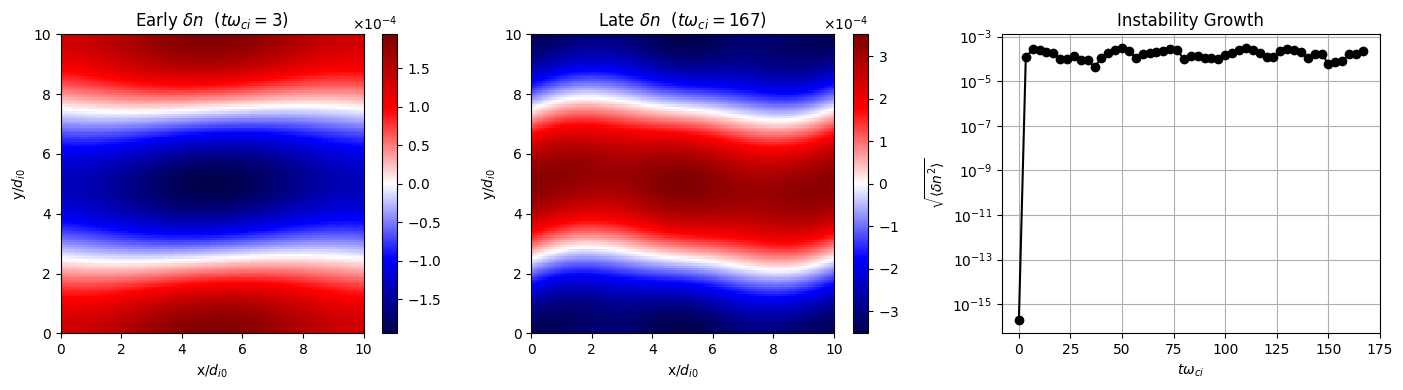

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg
import glob
from matplotlib.ticker import ScalarFormatter

# --------------------------------------------------
# Directory
# --------------------------------------------------

basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/drift_wave_study_mpi_stronger/"

# --------------------------------------------------
# Physical normalization
# --------------------------------------------------

qe = 1.0
me = 1.0
B0 = 1.0

wci = qe*B0/me     # cyclotron frequency
t_end = 100.0
num_frames = 30

dt_frame = t_end/num_frames

# --------------------------------------------------
# Detect files
# --------------------------------------------------

files = glob.glob(f"{basedir}/drift_wave_instability-elc_M0_*.gkyl")

steps = []

for f in files:
    step = int(f.split("_")[-1].split(".")[0])
    steps.append(step)

steps = sorted(steps)

print("Detected steps:", steps)

if len(steps) == 0:
    raise RuntimeError("No M0 files detected")

# --------------------------------------------------
# Load density
# --------------------------------------------------

def load_ne(step):

    data = pg.GData(f"{basedir}/drift_wave_instability-elc_M0_{step}.gkyl")
    interp = pg.GInterpModal(data,1,"ms")

    grid,values = interp.interpolate()

    x = grid[0]
    y = grid[1]

    ne = values[:,:,0]

    xc = 0.5*(x[:-1] + x[1:])
    yc = 0.5*(y[:-1] + y[1:])

    return xc,yc,ne

# --------------------------------------------------
# Density fluctuation
# --------------------------------------------------

def density_fluctuation(ne):

    mean_profile = np.mean(ne,axis=1)[:,None]
    dn = ne - mean_profile

    return dn

# --------------------------------------------------
# RMS fluctuation vs time
# --------------------------------------------------

rms = []
time = []

for s in steps:

    try:

        x,y,ne = load_ne(s)
        dn = density_fluctuation(ne)

        rms.append(np.sqrt(np.mean(dn**2)))

        t = s*dt_frame
        time.append(t*wci)

    except:
        break

steps = steps[:len(rms)]

print("Steps used:",steps)

# --------------------------------------------------
# Early and late snapshots
# --------------------------------------------------

early_step = steps[1]
late_step  = steps[-1]

x,y,ne_early = load_ne(early_step)
dn_early = density_fluctuation(ne_early)

x,y,ne_late = load_ne(late_step)
dn_late = density_fluctuation(ne_late)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig,axs = plt.subplots(1,3,figsize=(14,4))

# --------------------------------------------------
# Early δn
# --------------------------------------------------

im0 = axs[0].pcolormesh(x,y,dn_early.T,cmap="seismic")
# axs[0].set_title(f"Early $\\delta n$  ($t\\omega_{{ci}}={time[1]:.2f}$)")
axs[0].set_title(f"Early $\\delta n$  ($t\\omega_{{ci}}={time[1]:.0f}$)")
axs[0].set_xlabel("x/$d_{i0}$")
axs[0].set_ylabel("y/$d_{i0}$")

# plt.colorbar(im0,ax=axs[0])
cbar0 = plt.colorbar(im0, ax=axs[0])
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2,2))
cbar0.formatter = formatter
cbar0.update_ticks()

# --------------------------------------------------
# Late δn
# --------------------------------------------------

im1 = axs[1].pcolormesh(x,y,dn_late.T,cmap="seismic")
axs[1].set_title(f"Late $\\delta n$  ($t\\omega_{{ci}}={time[-1]:.0f}$)")
axs[1].set_xlabel("x/$d_{i0}$")
axs[1].set_ylabel("y/$d_{i0}$")

# plt.colorbar(im1,ax=axs[1])
cbar1 = plt.colorbar(im1, ax=axs[1])
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2,2))
cbar1.formatter = formatter
cbar1.update_ticks()

# --------------------------------------------------
# Growth curve
# --------------------------------------------------

axs[2].plot(time,rms,'o-',color='black')

axs[2].set_yscale("log")

axs[2].set_xlabel(r"$t\omega_{ci}$")
axs[2].set_ylabel(r"$\sqrt{\langle \delta n^2\rangle}$")

axs[2].set_title("Instability Growth")

axs[2].grid(True)

plt.tight_layout()
plt.savefig("drift_validation_3panel.png", dpi=600, bbox_inches="tight")

plt.show()

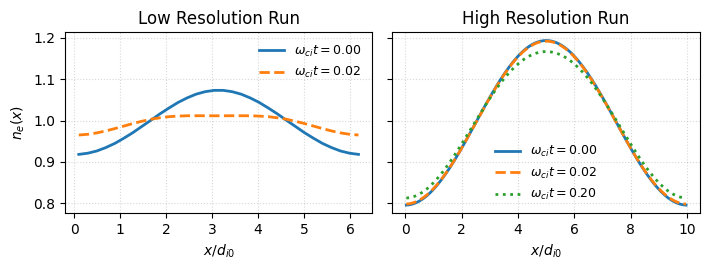

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg

# -----------------------------
# parameters
# -----------------------------

B0 = 1.0
qi = 1.0
mi = 25.0
wci = qi*B0/mi

dt = 0.1

step1 = 1
step2 = 4
step3 = 50

di0 = 1.0


# -----------------------------
# helper functions
# -----------------------------

def load_ne(run_dir, step):

    f = pg.GData(f"{run_dir}/drift_wave_instability-elc_M0_{step}.gkyl")
    interp = pg.GInterpModal(f,1,"ms")

    grid, values = interp.interpolate()

    x = grid[0]
    y = grid[1]

    # convert nodes → cell centers
    xc = 0.5*(x[:-1] + x[1:])

    ne = values[:,:,0]

    return xc, y, ne


def density_profile_1d(ne):
    return np.mean(ne,axis=1)


# -----------------------------
# LOW RESOLUTION RUN
# -----------------------------

run_low = "../drift_wave_study_true"

x_low, y, ne1 = load_ne(run_low, step1)
_, _, ne2 = load_ne(run_low, step2)

profile1_low = density_profile_1d(ne1)
profile2_low = density_profile_1d(ne2)

x_low_norm = x_low/di0


# -----------------------------
# HIGH RESOLUTION RUN
# -----------------------------

run_high = "."

x_high, y, ne1 = load_ne(run_high, step1)
_, _, ne2 = load_ne(run_high, step2)
_, _, ne3 = load_ne(run_high, step3)

profile1_high = density_profile_1d(ne1)
profile2_high = density_profile_1d(ne2)
profile3_high = density_profile_1d(ne3)

x_high_norm = x_high/di0


# -----------------------------
# time conversion
# -----------------------------

time1 = step1*dt*wci
time2 = step2*dt*wci
time3 = step3*dt*wci


# -----------------------------
# plotting
# -----------------------------

fig, ax = plt.subplots(
    1,2,
    figsize=(7.2,2.8),
    sharey=True
)


# LOW RES RUN

ax[0].plot(
    x_low_norm, profile1_low,
    linewidth=2,
    linestyle="-",
    label=f"$\\omega_{{ci}}t={time1:.2f}$"
)

ax[0].plot(
    x_low_norm, profile2_low,
    linewidth=2,
    linestyle="--",
    label=f"$\\omega_{{ci}}t={time2:.2f}$"
)

ax[0].set_title("Low Resolution Run")
ax[0].set_xlabel(r"$x/d_{i0}$")
ax[0].set_ylabel(r"$n_e(x)$")

ax[0].grid(True,linestyle=":",alpha=0.5)
ax[0].legend(frameon=False,fontsize=9)


# HIGH RES RUN

ax[1].plot(
    x_high_norm, profile1_high,
    linewidth=2,
    linestyle="-",
    label=f"$\\omega_{{ci}}t={time1:.2f}$"
)

ax[1].plot(
    x_high_norm, profile2_high,
    linewidth=2,
    linestyle="--",
    label=f"$\\omega_{{ci}}t={time2:.2f}$"
)

ax[1].plot(
    x_high_norm, profile3_high,
    linewidth=2,
    linestyle=":",
    label=f"$\\omega_{{ci}}t={time3:.2f}$"
)

ax[1].set_title("High Resolution Run")
ax[1].set_xlabel(r"$x/d_{i0}$")

ax[1].grid(True,linestyle=":",alpha=0.5)
ax[1].legend(frameon=False,fontsize=9)


plt.tight_layout()

plt.savefig(
    "density_profile_low_vs_high.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()